# Data Exploration with Droughts

Necessary Imports

In [456]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline
import matplotlib.dates as mdates 

In [457]:
county = "Kern"
df = pd.read_csv(f'../../data/{county.lower()}_agg_drought.csv')

In [458]:
df

,YEAR_MONTH,VFRate,FIRE_Acres_Burned,PRECIP,WIND_EventCount,WIND_AvgMPH,WIND_RunMiles,AQI_PM25,AQI_PM10,EARTHQUAKE_Total,PESTICIDE_Total,POUNDS_PRODUCT_APPLIED,Avg_Monthly_DSCI
0,2008-10,6.476629,0.0,0.04,0.0,3.483871,83.348387,78.0,76.0,0,1392.455039,689.3538,596.415
1,2008-11,6.110027,0.0,1.46,0.0,2.956667,70.930000,131.5,63.5,0,682.323659,341.5625,600.000
2,2008-12,5.499024,0.0,1.70,0.0,3.080645,73.777419,97.0,44.0,1,724.679851,461.0845,600.000
3,2009-01,3.734323,0.0,0.88,0.0,2.935484,70.329032,142.0,39.0,0,215.008252,257.3125,599.820
4,2009-02,3.975247,0.0,1.18,0.0,3.842857,92.107143,64.0,19.0,0,209.886979,133.2500,598.035
...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,2015-08,12.376954,0.0,0.79,0.0,3.622581,87.032258,61.0,60.0,0,2609.478922,1024.5380,1368.500
82,2015-09,15.329255,0.0,0.12,0.0,3.356667,80.520000,56.0,34.5,0,1355.016585,857.7083,1368.500
83,2015-10,16.918956,0.0,0.60,0.0,3.345161,80.422581,57.0,18.0,0,1841.226571,1669.6634,1368.500
84,2015-11,16.237656,0.0,0.90,0.0,3.063333,73.463333,78.5,9.5,0,1142.119879,470.9148,1368.500


In [459]:
df = df.rename(columns={'POUNDS_PRODUCT_APPLIED': 'RODENTICIDE_Total'})
print(df.head())

  YEAR_MONTH    VFRate  FIRE_Acres_Burned  PRECIP  WIND_EventCount  \
0    2008-10  6.476629                0.0    0.04              0.0   
1    2008-11  6.110027                0.0    1.46              0.0   
2    2008-12  5.499024                0.0    1.70              0.0   
3    2009-01  3.734323                0.0    0.88              0.0   
4    2009-02  3.975247                0.0    1.18              0.0   

   WIND_AvgMPH  WIND_RunMiles  AQI_PM25  AQI_PM10  EARTHQUAKE_Total  \
0     3.483871      83.348387      78.0      76.0                 0   
1     2.956667      70.930000     131.5      63.5                 0   
2     3.080645      73.777419      97.0      44.0                 1   
3     2.935484      70.329032     142.0      39.0                 0   
4     3.842857      92.107143      64.0      19.0                 0   

   PESTICIDE_Total  RODENTICIDE_Total  Avg_Monthly_DSCI  
0      1392.455039           689.3538           596.415  
1       682.323659           341.562

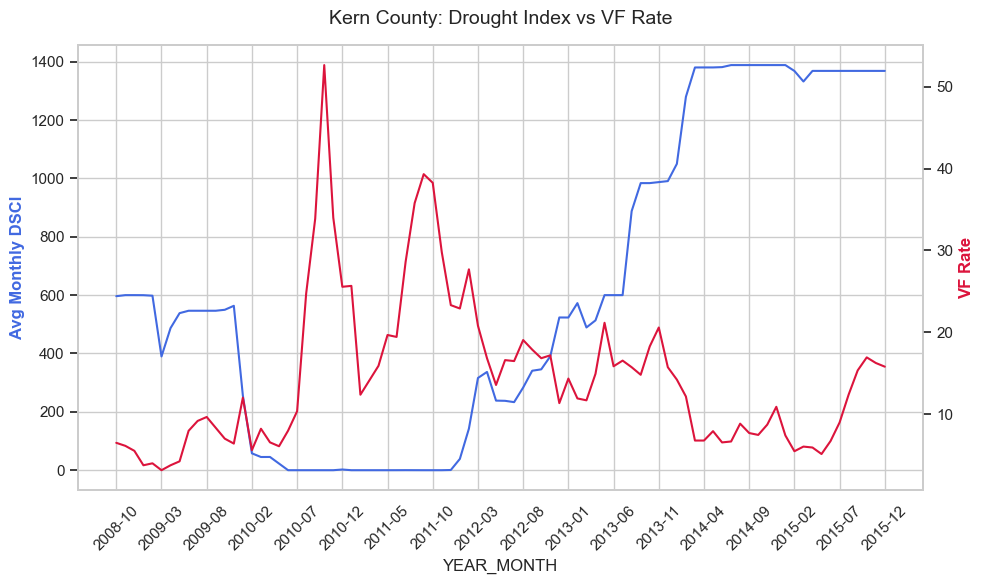

In [460]:
sns.set_theme(style="whitegrid") 

fig, ax1 = plt.subplots(figsize=(10, 6))

ax2 = ax1.twinx()

sns.lineplot(data=df, x='YEAR_MONTH', y='Avg_Monthly_DSCI', ax=ax1, color='royalblue')
sns.lineplot(data=df, x='YEAR_MONTH', y='VFRate', ax=ax2, color='crimson')

ax1.tick_params(axis='x', rotation=45) 
current_ticks = ax1.get_xticks()
ax1.set_xticks(current_ticks[::5])

ax1.set_title(f"{county} County: Drought Index vs VF Rate", fontsize=14, pad=15)
ax1.set_ylabel("Avg Monthly DSCI", color='royalblue', fontweight='bold')
ax2.set_ylabel("VF Rate", color='crimson', fontweight='bold')
ax2.grid(False)
plt.tight_layout()
plt.show()


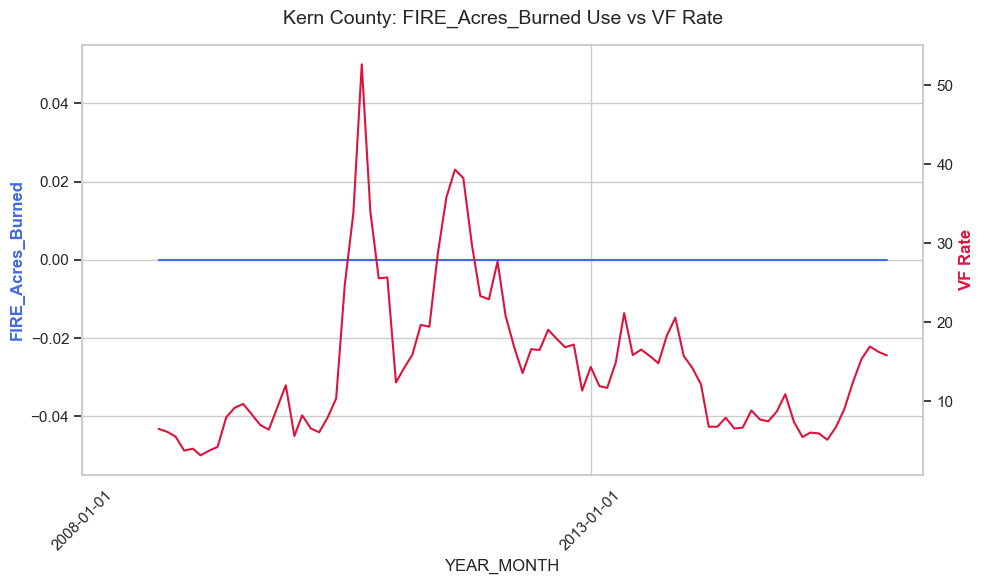

In [477]:
sns.set_theme(style="whitegrid") 
tgt_variable = "FIRE_Acres_Burned"
fig, ax1 = plt.subplots(figsize=(10, 6))

ax2 = ax1.twinx()

sns.lineplot(data=df, x='YEAR_MONTH', y=f"{tgt_variable}", ax=ax1, color='royalblue')
sns.lineplot(data=df, x='YEAR_MONTH', y='VFRate', ax=ax2, color='crimson')

ax1.tick_params(axis='x', rotation=45) 
current_ticks = ax1.get_xticks()
ax1.set_xticks(current_ticks[::5])

ax1.set_title(f"{county} County: {tgt_variable} Use vs VF Rate", fontsize=14, pad=15)
ax1.set_ylabel(f"{tgt_variable}", color='royalblue', fontweight='bold')
ax2.set_ylabel("VF Rate", color='crimson', fontweight='bold')
ax2.grid(False)
plt.tight_layout()
plt.show()


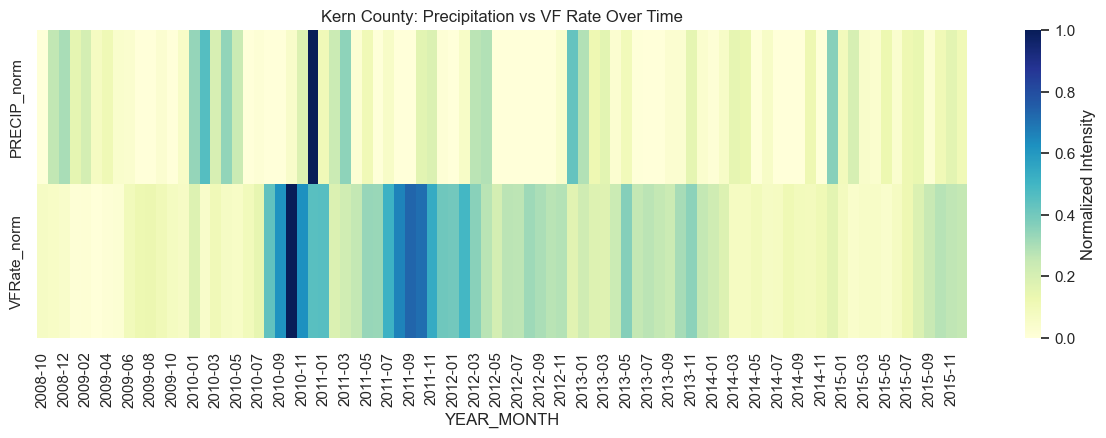

In [462]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Prepare data: normalize the scales so they share a 0-1 range for the colors
df_norm = df.copy()
df_norm['PRECIP_norm'] = (df['PRECIP'] - df['PRECIP'].min()) / (df['PRECIP'].max() - df['PRECIP'].min())
df_norm['VFRate_norm'] = (df['VFRate'] - df['VFRate'].min()) / (df['VFRate'].max() - df['VFRate'].min())

# Transpose for heatmap format
heat_df = df_norm.set_index('YEAR_MONTH')[['PRECIP_norm', 'VFRate_norm']].T

plt.figure(figsize=(15, 4))
sns.heatmap(heat_df, cmap="YlGnBu", cbar_kws={'label': 'Normalized Intensity'})
plt.title(f"{county} County: Precipitation vs VF Rate Over Time")
plt.show()

In [463]:
df.describe()

,VFRate,FIRE_Acres_Burned,PRECIP,WIND_EventCount,WIND_AvgMPH,WIND_RunMiles,AQI_PM25,AQI_PM10,EARTHQUAKE_Total,PESTICIDE_Total,RODENTICIDE_Total,Avg_Monthly_DSCI
count,86.000000,86.0,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000,86.000000
mean,14.533659,0.0,0.621860,0.069767,3.507443,84.177244,70.906977,35.174419,0.209302,1915.387566,1556.616908,614.954738
std,9.421224,0.0,0.842782,0.298652,0.590233,14.181081,20.361658,14.447016,0.652890,1592.346562,1409.222792,533.667650
min,3.132013,0.0,0.000000,0.000000,2.035484,48.922581,47.000000,6.000000,0.000000,0.000000,15.000000,0.000000
25%,7.085287,0.0,0.040000,0.000000,3.066944,73.541855,59.000000,25.000000,0.000000,889.331455,589.214650,45.278125
50%,12.367630,0.0,0.320000,0.000000,3.515108,84.504839,64.000000,34.000000,0.000000,1649.290420,1175.330800,546.480000
75%,17.695311,0.0,0.895000,0.000000,3.953548,94.888710,76.500000,42.875000,0.000000,2384.432694,2071.412975,1319.066250
max,52.640272,0.0,5.650000,2.000000,4.729032,113.425806,147.000000,81.000000,5.000000,9765.795470,7602.513700,1388.400000


array([[<Axes: title={'center': 'VFRate'}>,
        <Axes: title={'center': 'FIRE_Acres_Burned'}>,
        <Axes: title={'center': 'PRECIP'}>],
       [<Axes: title={'center': 'WIND_EventCount'}>,
        <Axes: title={'center': 'WIND_AvgMPH'}>,
        <Axes: title={'center': 'WIND_RunMiles'}>],
       [<Axes: title={'center': 'AQI_PM25'}>,
        <Axes: title={'center': 'AQI_PM10'}>,
        <Axes: title={'center': 'EARTHQUAKE_Total'}>],
       [<Axes: title={'center': 'PESTICIDE_Total'}>,
        <Axes: title={'center': 'RODENTICIDE_Total'}>,
        <Axes: title={'center': 'Avg_Monthly_DSCI'}>]], dtype=object)

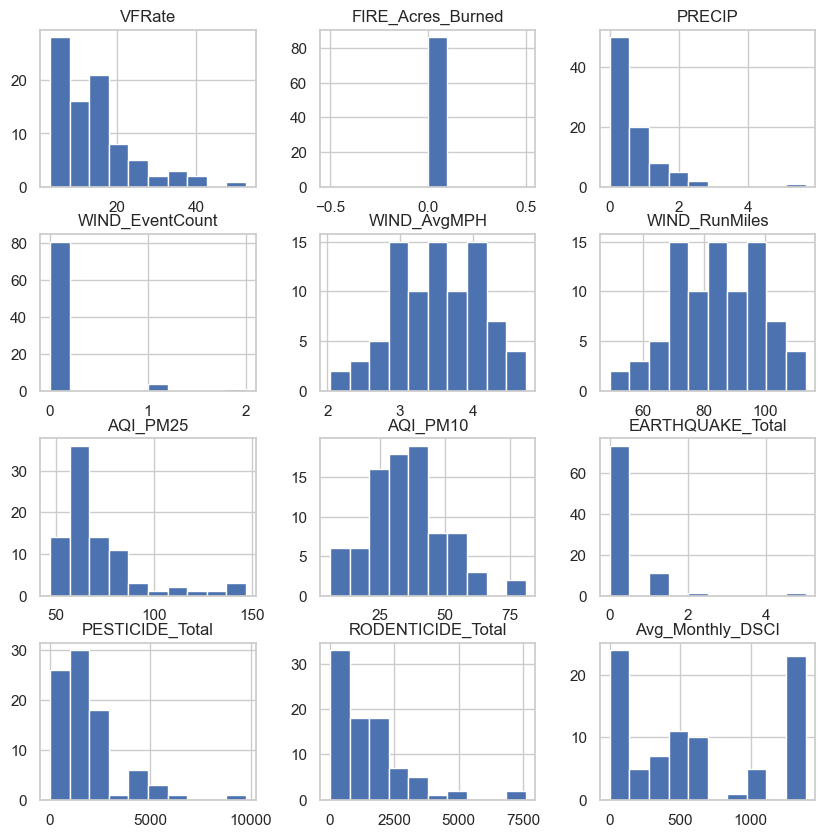

In [464]:
df.hist(figsize=(10,10))

Observations:
- Pesticide total is definitely right-skewed with some outliers
- Similarly with Pounds of Product Applied (Need to rename to Rodenticide)
- Earthquake is kind of weird, so low
- Wind event count needs some feature engineering
- AQI PM_25 maybe? Idk about AQI_PM10... almost normalish
- Fire Acres Burned and Precip are definitely right-skewed

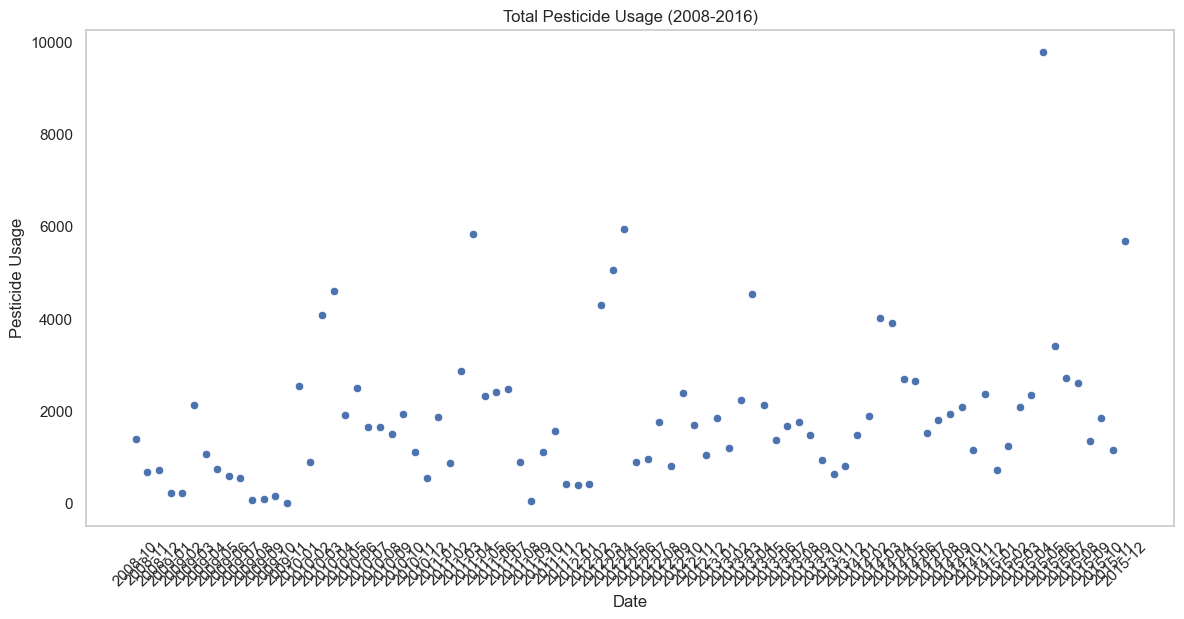

In [465]:
plt.figure(figsize=(12,6))
sns.scatterplot(df, x = "YEAR_MONTH", y = "PESTICIDE_Total")
plt.title("Total Pesticide Usage (2008-2016)")
plt.xlabel("Date")
plt.ylabel("Pesticide Usage")
plt.tight_layout()
plt.grid(False)
plt.xticks(rotation=45)
plt.show()

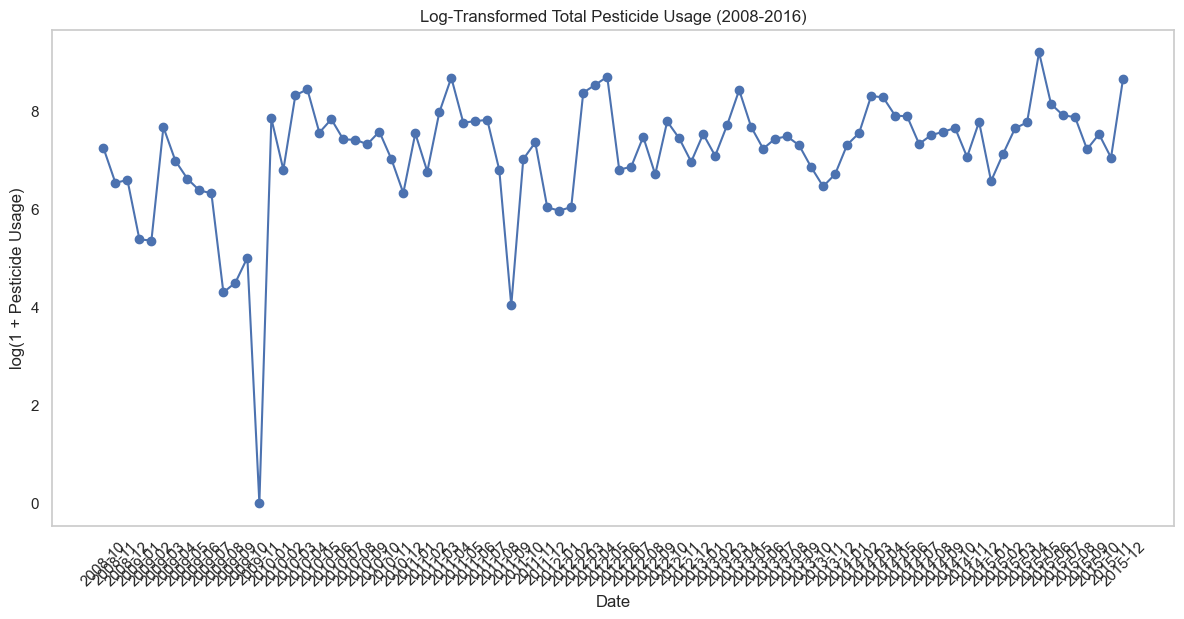

In [466]:
plt.figure(figsize=(12,6))
plt.plot(df["YEAR_MONTH"], np.log1p(df["PESTICIDE_Total"]), marker="o", linestyle="-")
plt.title("Log-Transformed Total Pesticide Usage (2008-2016)")
plt.xlabel("Date")
plt.ylabel("log(1 + Pesticide Usage)")
plt.tight_layout()
plt.grid(False)
plt.xticks(rotation=45)
plt.show()


Text(0.5, 1.0, 'Histogram of log(1+Pesticide Usage)')

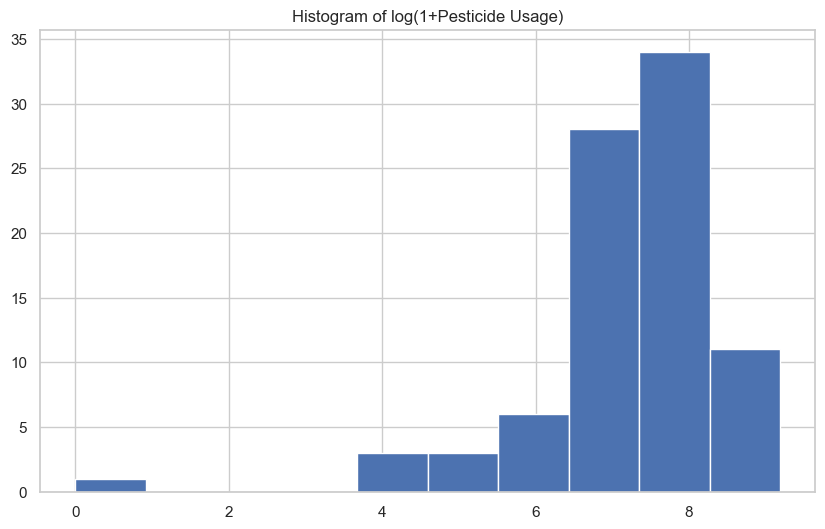

In [467]:
plt.figure(figsize=(10,6))
plt.hist(np.log1p(df["PESTICIDE_Total"]))
plt.title("Histogram of log(1+Pesticide Usage)")

Normality check for log(1+Rodenticide) has a p-value = 0.0005366687670354246


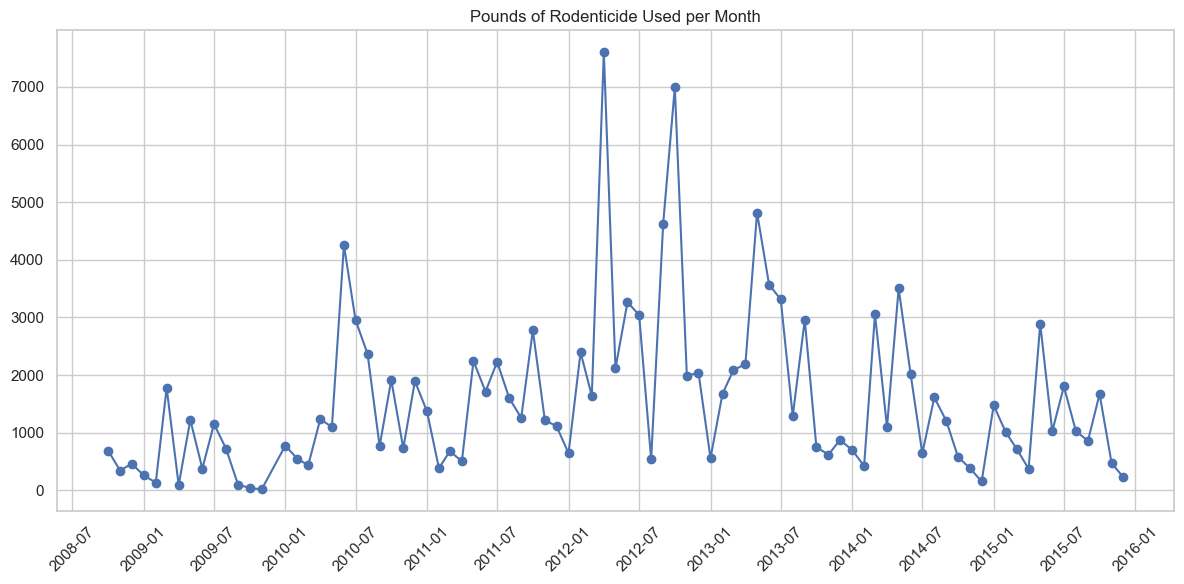

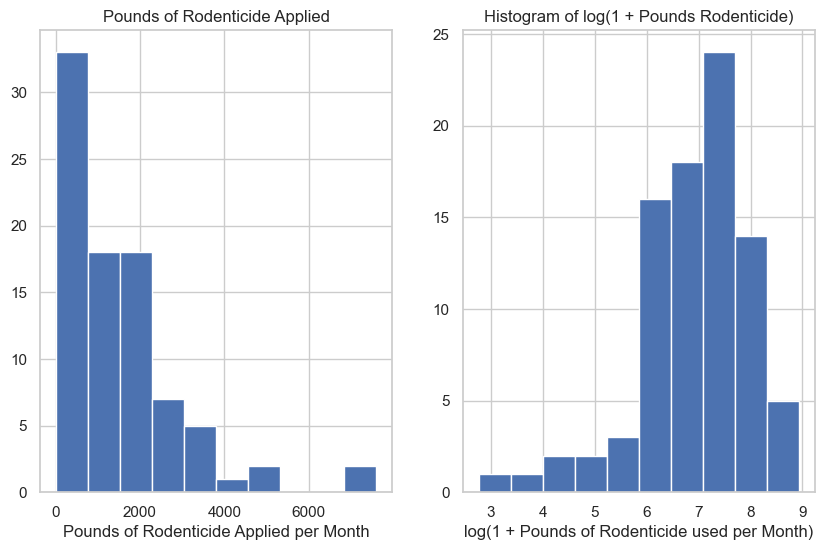

In [468]:
df["YEAR_MONTH"] = pd.to_datetime(df["YEAR_MONTH"])

fig, ax = plt.subplots(figsize=(12,6))
plt.plot(df["YEAR_MONTH"], df["RODENTICIDE_Total"], marker="o", linestyle="-")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.grid(True)
plt.title("Pounds of Rodenticide Used per Month")
plt.xticks(rotation=45)
plt.tight_layout()



plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
plt.hist(df["RODENTICIDE_Total"])
plt.title("Pounds of Rodenticide Applied")
plt.xlabel("Pounds of Rodenticide Applied per Month")
plt.subplot(1,2,2)
plt.hist(np.log1p(df["RODENTICIDE_Total"]))
plt.title("Histogram of log(1 + Pounds Rodenticide)")
plt.xlabel("log(1 + Pounds of Rodenticide used per Month)")

from scipy.stats import shapiro 
stats, pval = shapiro(np.log1p(df["RODENTICIDE_Total"]))
print(f"Normality check for log(1+Rodenticide) has a p-value = {pval}")



Text(0, 0.5, 'log(1+ lbs Rodenticide) per Month')

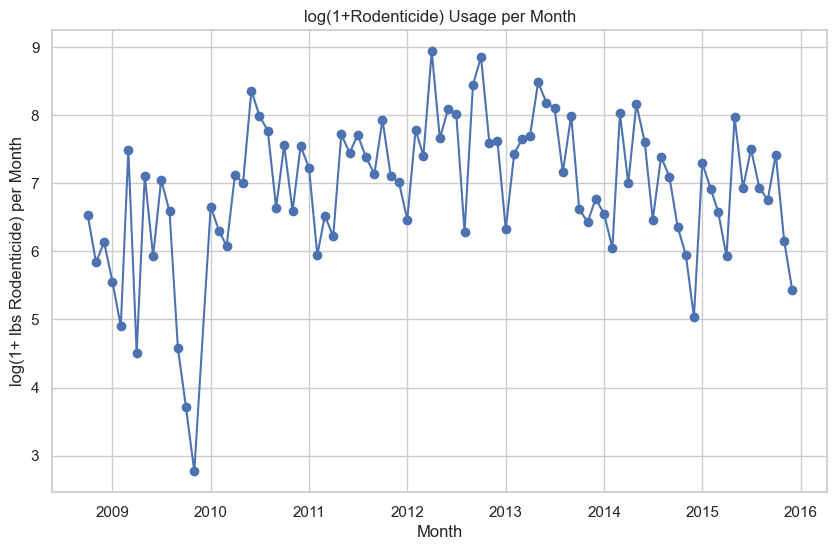

In [469]:
plt.figure(figsize=(10,6))
plt.plot(df["YEAR_MONTH"], np.log1p(df["RODENTICIDE_Total"]), marker="o", linestyle="-")
plt.title("log(1+Rodenticide) Usage per Month")
plt.xlabel("Month")
plt.ylabel("log(1+ lbs Rodenticide) per Month")

# Observations and Next Steps:

## Observations

In doing this data exploration, I have noticed that we have some continuous variables that are heavily right-skewed. This means we have a lot of counts clustered aroung the same values but a set of large outliers that create a fat right tail. In order to modify this behavior, we can use the log tranform from `np.log1p(data)`. As seen above, this made the Rodenticide normal (Shapiro-Wilk test p = .08). 

## Next Steps

Next steps are to check to see what other right skewed data is useful to transform and if its normal after the log transformation. Once this is done, I will create a new dataframe and data files with these values and see how the LSTM performs. 

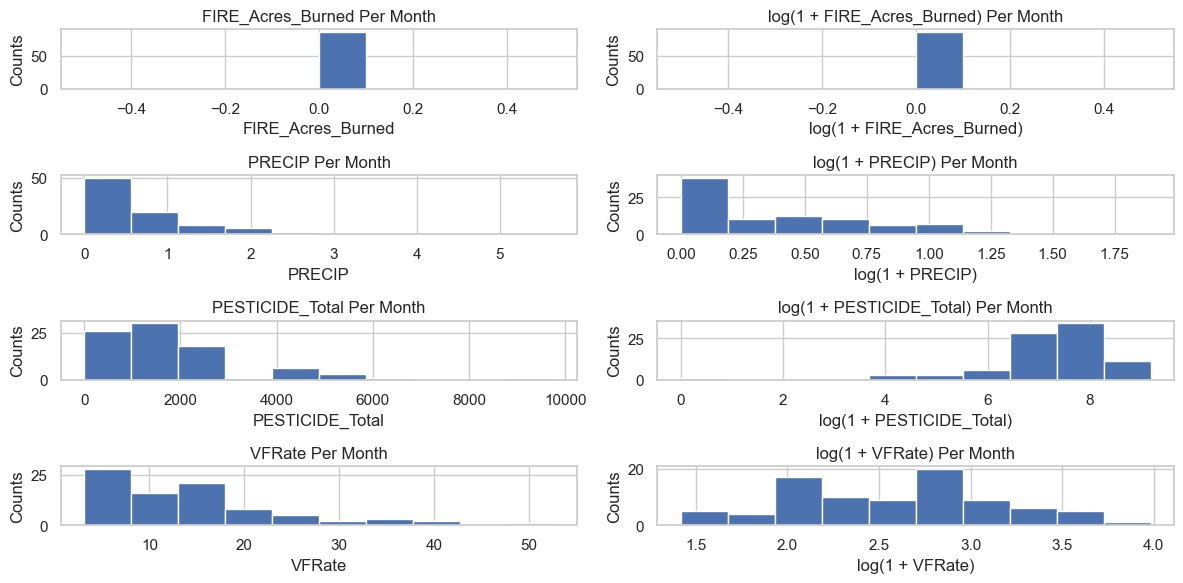

In [470]:
# Other Data to try out:
# Pesticide Data, Fire, Precip 
lbls_in_question = ["FIRE_Acres_Burned", "PRECIP", "PESTICIDE_Total", "VFRate"]
plt.figure(figsize=(12,6))
lblIdx = 0;
for ii in range(1, 9):
  plt.subplot(4,2,ii)
  if ii % 2 == 0:
    plt.hist(np.log1p(df[lbls_in_question[lblIdx]]))
    plt.title(f"log(1 + {lbls_in_question[lblIdx]}) Per Month")
    plt.xlabel(f"log(1 + {lbls_in_question[lblIdx]})")
    plt.ylabel("Counts")
    lblIdx = lblIdx + 1
  else:
    plt.hist(df[lbls_in_question[lblIdx]])
    plt.title(f"{lbls_in_question[lblIdx]} Per Month")
    plt.xlabel(f"{lbls_in_question[lblIdx]}")
    plt.ylabel("Counts")

plt.tight_layout()

In [471]:
stats, pval = shapiro(np.log1p(df["VFRate"]))
print(f"Normality check for log(1+VFRate) has a p-value = {pval}")

Normality check for log(1+VFRate) has a p-value = 0.25131793388552875


In [472]:
_, pvalDSCI = shapiro(df["Avg_Monthly_DSCI"])
_, pvalLogDSCI = shapiro(np.log1p(df["Avg_Monthly_DSCI"]))
print(f"original DSCI normality pval: {pvalDSCI}")
print(f"log transform DSCI normality pval: {pvalLogDSCI}")

original DSCI normality pval: 5.008193874908576e-08
log transform DSCI normality pval: 1.7143598950172835e-11


It seems that Precipitation will not work will with the `np.log1p` transformation but the other variables seem to be okay. 

Now, the next stage is to create the datasets as CSV files. I will create the following:

- Baseline: typical CSV
- logVFRate: log1p of VFRate
- log1pFeats: CSV with log1p of Fire, Pesticide, Rodenticide
- log1pAll: CSV with log1p of VFRate and features 

In [473]:
'''df_new = df.copy()
print(df_new.head())
df_new.to_csv(f'../../data/{county.lower()}_agg_drought_baseline.csv', index=False)'''

"df_new = df.copy()\nprint(df_new.head())\ndf_new.to_csv(f'../../data/{county.lower()}_agg_drought_baseline.csv', index=False)"

In [474]:
df_vflog = df.copy()
df_vflog["VFRate"] = np.log1p(df["VFRate"])
df_vflog = df_vflog.rename(columns={"VFRate" : "log1pVFRate"})
print(df_vflog.head())
'''df_vflog.to_csv(f'../../data/{county.lower()}_agg_drought_vflog.csv', index=False)'''

  YEAR_MONTH  log1pVFRate  FIRE_Acres_Burned  PRECIP  WIND_EventCount  \
0 2008-10-01     2.011782                0.0    0.04              0.0   
1 2008-11-01     1.961506                0.0    1.46              0.0   
2 2008-12-01     1.871652                0.0    1.70              0.0   
3 2009-01-01     1.554839                0.0    0.88              0.0   
4 2009-02-01     1.604475                0.0    1.18              0.0   

   WIND_AvgMPH  WIND_RunMiles  AQI_PM25  AQI_PM10  EARTHQUAKE_Total  \
0     3.483871      83.348387      78.0      76.0                 0   
1     2.956667      70.930000     131.5      63.5                 0   
2     3.080645      73.777419      97.0      44.0                 1   
3     2.935484      70.329032     142.0      39.0                 0   
4     3.842857      92.107143      64.0      19.0                 0   

   PESTICIDE_Total  RODENTICIDE_Total  Avg_Monthly_DSCI  
0      1392.455039           689.3538           596.415  
1       682.323659

"df_vflog.to_csv(f'../../data/{county.lower()}_agg_drought_vflog.csv', index=False)"

In [475]:
df_featurelog = df.copy()
df_featurelog["FIRE_Acres_Burned"] = np.log1p(df["FIRE_Acres_Burned"])
df_featurelog["PESTICIDE_Total"] = np.log1p(df["PESTICIDE_Total"])
df_featurelog["RODENTICIDE_Total"] = np.log1p(df["RODENTICIDE_Total"])
df_featurelog = df_featurelog.rename(columns={"FIRE_Acres_Burned" : "log1pFire", "PESTICIDE_Total" : "log1pPESTICIDE", "RODENTICIDE_Total" : "log1pRODENTICIDE"})
print(df_featurelog.head())
# df_featurelog.to_csv(f'../../data/{county.lower()}_agg_drought_featlog.csv', index=False)

  YEAR_MONTH    VFRate  log1pFire  PRECIP  WIND_EventCount  WIND_AvgMPH  \
0 2008-10-01  6.476629        0.0    0.04              0.0     3.483871   
1 2008-11-01  6.110027        0.0    1.46              0.0     2.956667   
2 2008-12-01  5.499024        0.0    1.70              0.0     3.080645   
3 2009-01-01  3.734323        0.0    0.88              0.0     2.935484   
4 2009-02-01  3.975247        0.0    1.18              0.0     3.842857   

   WIND_RunMiles  AQI_PM25  AQI_PM10  EARTHQUAKE_Total  log1pPESTICIDE  \
0      83.348387      78.0      76.0                 0        7.239542   
1      70.930000     131.5      63.5                 0        6.526969   
2      73.777419      97.0      44.0                 1        6.587109   
3      70.329032     142.0      39.0                 0        5.375317   
4      92.107143      64.0      19.0                 0        5.351322   

   log1pRODENTICIDE  Avg_Monthly_DSCI  
0          6.537204           596.415  
1          5.836454     

In [476]:
df_vfandfeatlog = df.copy()
df_vfandfeatlog["VFRate"] = np.log1p(df["VFRate"])
df_vfandfeatlog["FIRE_Acres_Burned"] = np.log1p(df["FIRE_Acres_Burned"])
df_vfandfeatlog["PESTICIDE_Total"] = np.log1p(df["PESTICIDE_Total"])
df_vfandfeatlog["RODENTICIDE_Total"] = np.log1p(df["RODENTICIDE_Total"])
df_vfandfeatlog = df_vfandfeatlog.rename(columns={"VFRate" : "log1pVFRate", "FIRE_Acres_Burned" : "log1pFire", "PESTICIDE_Total" : "log1pPESTICIDE", "RODENTICIDE_Total" : "log1pRODENTICIDE"})
print(df_vfandfeatlog.head())
# df_vfandfeatlog.to_csv(f'../../data/{county.lower()}_agg_drought_vfandfeatlog.csv', index=False)'''

  YEAR_MONTH  log1pVFRate  log1pFire  PRECIP  WIND_EventCount  WIND_AvgMPH  \
0 2008-10-01     2.011782        0.0    0.04              0.0     3.483871   
1 2008-11-01     1.961506        0.0    1.46              0.0     2.956667   
2 2008-12-01     1.871652        0.0    1.70              0.0     3.080645   
3 2009-01-01     1.554839        0.0    0.88              0.0     2.935484   
4 2009-02-01     1.604475        0.0    1.18              0.0     3.842857   

   WIND_RunMiles  AQI_PM25  AQI_PM10  EARTHQUAKE_Total  log1pPESTICIDE  \
0      83.348387      78.0      76.0                 0        7.239542   
1      70.930000     131.5      63.5                 0        6.526969   
2      73.777419      97.0      44.0                 1        6.587109   
3      70.329032     142.0      39.0                 0        5.375317   
4      92.107143      64.0      19.0                 0        5.351322   

   log1pRODENTICIDE  Avg_Monthly_DSCI  
0          6.537204           596.415  
1     